In [1]:
!pip install nltk

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

In [2]:
import os
import json
import zipfile
import re
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string
import seaborn as sns
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
import pickle
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,precision_score

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
!kaggle datasets download mexwell/fake-reviews-dataset

Dataset URL: https://www.kaggle.com/datasets/mexwell/fake-reviews-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 4.78M/4.78M [00:01<00:00, 2.93MB/s]



In [5]:
!ls

fake-reviews-dataset.zip  sample_data


In [6]:
with zipfile.ZipFile("fake-reviews-dataset.zip", "r") as zip_ref:
    zip_ref.extractall()

In [7]:
!ls

'fake reviews dataset.csv'   fake-reviews-dataset.zip   sample_data


In [8]:
# Loading the dataset to a pandas dataframe
df = pd.read_csv("fake reviews dataset.csv")

In [9]:
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [10]:
df.tail()

,category,rating,label,text_
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...
40431,Clothing_Shoes_and_Jewelry_5,5.0,OR,I work in the wedding industry and have to wor...


In [11]:
df.drop(columns = {'category'}, inplace = True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rating  40432 non-null  float64
 1   label   40432 non-null  object 
 2   text_   40432 non-null  object 
dtypes: float64(1), object(2)
memory usage: 947.8+ KB


In [13]:
df.rename(columns = {'text_': 'text'}, inplace = True)

In [14]:
df.head()

,rating,label,text
0,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,5.0,CG,"love it, a great upgrade from the original. I..."
2,5.0,CG,This pillow saved my back. I love the look and...
3,1.0,CG,"Missing information on how to use it, but it i..."
4,5.0,CG,Very nice set. Good quality. We have had the s...


In [15]:
def encode_label(df):
    labels = {
        'CG': 0,
        'OR': 1
    }

    df['target'] = df['label'].map(labels)

    return df

In [16]:
df = encode_label(df)
df['target'] = df['target'].fillna(0).replace([np.inf, -np.inf], 0)
df['target'] = df['target'].astype(int)
df.head()

,rating,label,text,target
0,5.0,CG,"Love this! Well made, sturdy, and very comfor...",0
1,5.0,CG,"love it, a great upgrade from the original. I...",0
2,5.0,CG,This pillow saved my back. I love the look and...,0
3,1.0,CG,"Missing information on how to use it, but it i...",0
4,5.0,CG,Very nice set. Good quality. We have had the s...,0


In [17]:
df.drop(columns = {'rating', 'label'}, inplace = True)

In [18]:
df = df.sample(frac=1).reset_index(drop=True)
df.sample(10)

,text,target
40324,Girls weekend in Vegas and it was just as com...,0
2422,"Wow, these boots are very light and they have ...",1
18343,"As always, Michael Pollan delivers a fascinati...",1
8251,No more breaking my back. It's an inexpensive ...,0
37556,Great book. I stayed up all night reading it. ...,0
28869,Honestly this is gorgeous. I have the wide kn...,0
21666,"It is a fake arduino, it works but is not genu...",1
12681,These shoes appear to have been discontinued b...,1
33569,I've got a short neck and an open neck and the...,0
10527,I really enjoy novels involving angels and dem...,1


In [19]:
df.isnull().sum()

,0
text,0
target,0


In [20]:
df.duplicated().sum()

np.int64(20)

In [21]:
df.drop_duplicates(inplace = True)

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['target'].value_counts()

,count
target,
1,20215
0,20197


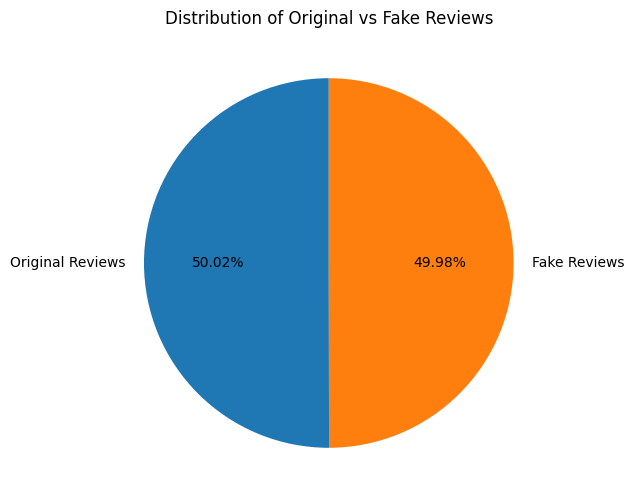

In [25]:
plt.figure(figsize=(6,6))
plt.pie(
    df['target'].value_counts(),
    labels=['Original Reviews', 'Fake Reviews'],
    autopct="%0.2f%%",
    startangle=90
)
plt.title("Distribution of Original vs Fake Reviews")
plt.show()

In [26]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [27]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [28]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,A great size and shape and it is nice to have ...,1,176,40,2
1,These glasses work great. They are an easy to ...,0,376,87,8
2,Great book... though with a silly ending that ...,1,131,28,1
3,My class loves this set! We sing the song and ...,1,137,30,3
4,Very cute story. I loved reading it and the ch...,0,120,24,3


In [29]:
df.describe()

,target,num_characters,num_words,num_sentences
count,40412.000000,40412.000000,40412.000000,40412.000000
mean,0.500223,351.365337,76.691131,5.277071
std,0.500006,369.871842,79.242859,4.915033
min,0.000000,24.000000,2.000000,1.000000
25%,0.000000,107.000000,24.000000,2.000000
50%,1.000000,198.000000,44.000000,3.000000
75%,1.000000,439.000000,96.000000,6.000000
max,1.000000,2827.000000,510.000000,133.000000


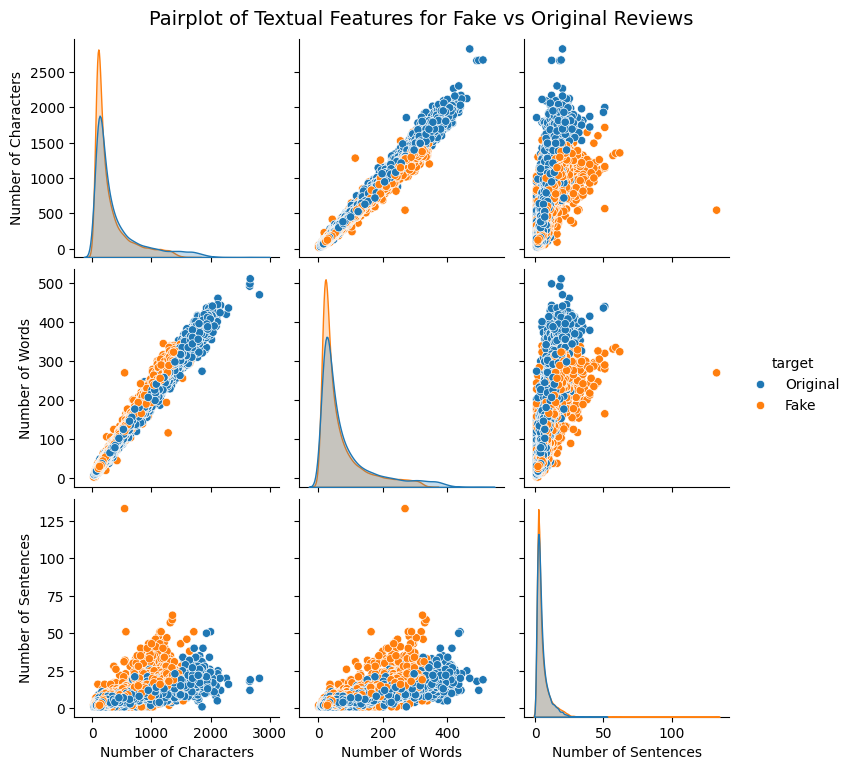

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only relevant features
plot_df = df[['num_characters', 'num_words', 'num_sentences', 'target']].copy()

# Map target for readability
plot_df['target'] = plot_df['target'].map({
    0: 'Fake',
    1: 'Original'
})

# Create pairplot
g = sns.pairplot(
    plot_df,
    hue='target',
    diag_kind='kde',
    corner=False   # ensures full 3x3 grid (9 plots)
)

# custom axis lables
labels = {
    'num_characters': 'Number of Characters',
    'num_words': 'Number of Words',
    'num_sentences': 'Number of Sentences'
}

for i, row in enumerate(g.axes):
    for j, ax in enumerate(row):
        if ax is not None:
            x_var = plot_df.columns[j]
            y_var = plot_df.columns[i]

            if x_var in labels:
                ax.set_xlabel(labels[x_var], fontsize=10)
            if y_var in labels:
                ax.set_ylabel(labels[y_var], fontsize=10)

# Title
g.fig.suptitle(
    "Pairplot of Textual Features for Fake vs Original Reviews",
    y=1.02,
    fontsize=14
)

plt.show()

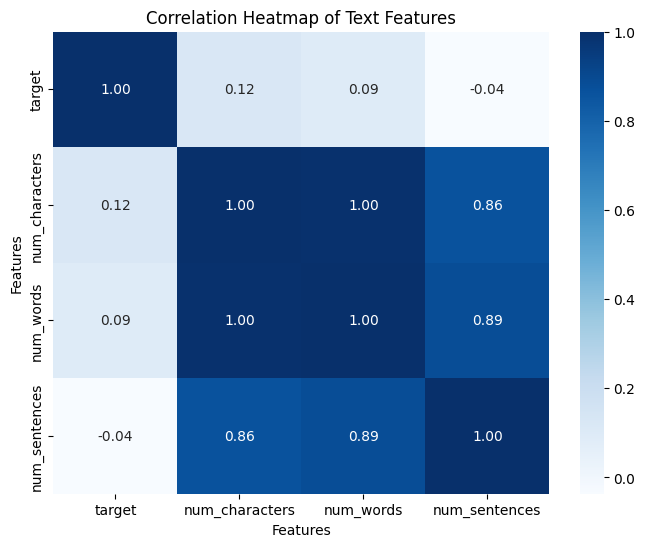

In [33]:
df_numeric = df.select_dtypes(include = 'number')
plt.figure(figsize=(8,6))

sns.heatmap(
    df_numeric.corr(),
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Correlation Heatmap of Text Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.show()

In [34]:
ps = PorterStemmer()

In [35]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [38]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [39]:
df['transformed_text'] = df['text'].apply(transform_text)

In [40]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,A great size and shape and it is nice to have ...,1,176,40,2,great size shape nice tray option yellow light...
1,These glasses work great. They are an easy to ...,0,376,87,8,glass work great easi use comfort wear bit bul...
2,Great book... though with a silly ending that ...,1,131,28,1,great book though silli end remind antic tower...
3,My class loves this set! We sing the song and ...,1,137,30,3,class love set sing song move monkey felt boar...
4,Very cute story. I loved reading it and the ch...,0,120,24,3,cute stori love read charact definit read read...


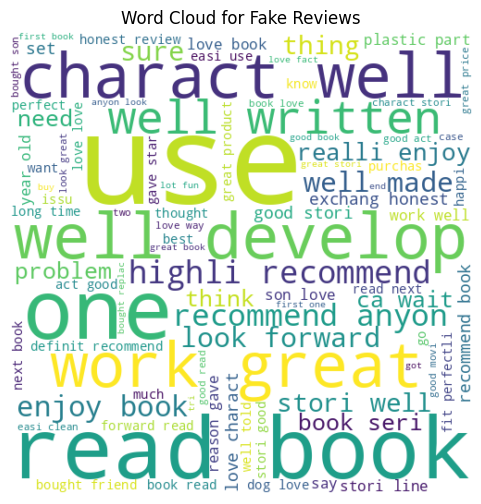

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Create word cloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

fake_wc = wc.generate(
    df[df['target'] == 0]['transformed_text'].str.cat(sep=" ")
)

# Display
plt.figure(figsize=(15,6))
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Fake Reviews")
plt.show()

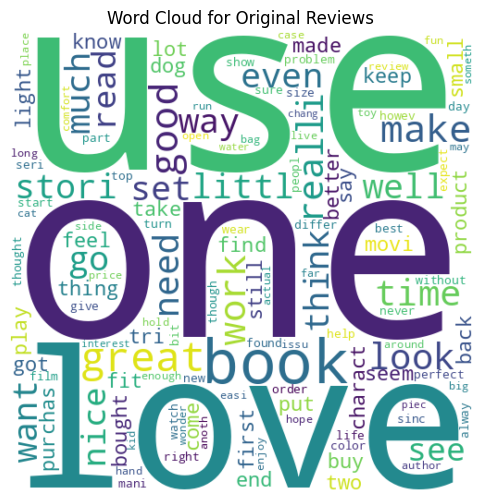

In [43]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

original_wc = wc.generate(
    df[df['target'] == 1]['transformed_text'].str.cat(sep=" ")
)

plt.figure(figsize=(15,6))
plt.imshow(original_wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Original Reviews")
plt.show()

In [44]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [45]:
print(X.shape)
print(y.shape)

(40412, 3000)
(40412,)


In [46]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=32)

In [47]:
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [48]:
clfs = {
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'xgb':xgb
}

In [49]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')

    return accuracy,precision

In [50]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

In [51]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [52]:
performance_df.reset_index(drop = True)

,Algorithm,Accuracy,Precision
0,LR,0.851788,0.851788
1,NB,0.834715,0.835264
2,RF,0.831003,0.832505
3,xgb,0.811704,0.813622
4,AdaBoost,0.672151,0.676220
5,DT,0.605097,0.654782
6,KN,0.502165,0.531326


In [53]:
mnb = MultinomialNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

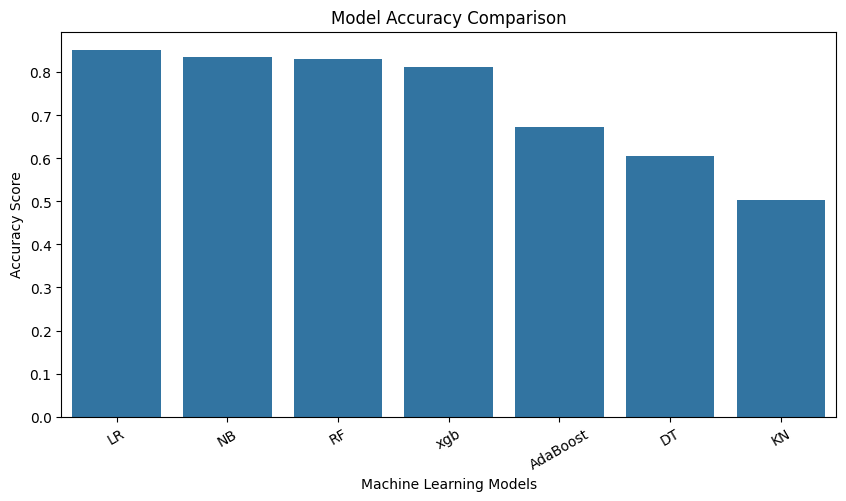

In [54]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Algorithm',
    y='Accuracy',
    data=performance_df
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")

plt.xticks(rotation=30)
plt.show()

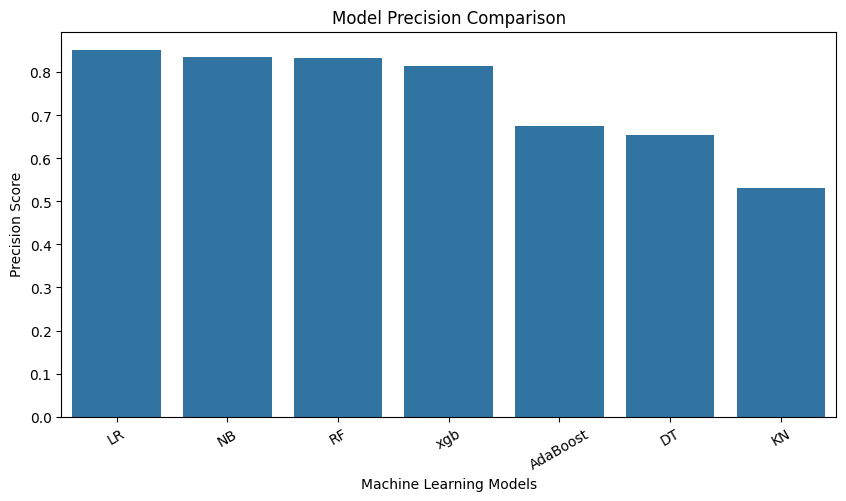

In [55]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Algorithm',
    y='Precision',
    data=performance_df
)

plt.title("Model Precision Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Precision Score")

plt.xticks(rotation=30)
plt.show()

In [56]:
voting = VotingClassifier(estimators=[('LR', lrc), ('nb', mnb), ('RF', rfc)],voting='soft')

In [57]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('LR',
                              LogisticRegression(penalty='l1',
                                                 solver='liblinear')),
                             ('nb', MultinomialNB()),
                             ('RF',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [58]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.865396511196338
Precision 0.8733602421796165


In [59]:
estimators = [('LR', lrc), ('nb', mnb), ('RF', rfc)]
final_estimator = RandomForestClassifier(n_estimators=50, random_state=2)

In [60]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [61]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.8526537176790796
Precision 0.855613642021409
